# Differentiable phase physics smoke test

This notebook keeps the example intentionally small and uses the cached vortex-disc fixture that already exists in the repo. The measured phase is explicitly rescaled so the masked loss starts at an easy-to-see value instead of looking numerically negligible.


In [28]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import unxt as u

jax.config.update("jax_enable_x64", True)

from libertem_holo.base.mbir import (
    forward_phase_from_density_and_magnetization,
    load_vortex_disc_fixture,
)


def crop_center(values, size):
    start = (values.shape[0] - size) // 2
    stop = start + size
    if values.ndim == 3:
        return values[start:stop, start:stop, start:stop]
    return values[start:stop, start:stop, start:stop, :]


fixture = load_vortex_disc_fixture(32)
rho = crop_center(np.asarray(fixture["rho_true"], dtype=np.float32), 32)
m_true = crop_center(np.asarray(fixture["m_true"], dtype=np.float32), 32)
pixel_size = u.Quantity(float(fixture["pixel_size_nm"]), "nm")
print(rho.shape)
phi_true = jnp.asarray(
    np.asarray(
        forward_phase_from_density_and_magnetization(
            rho=rho,
            magnetization_3d=m_true,
            pixel_size=pixel_size,
            axis="z",
        ),
        dtype=np.float32,
    )
)
mask = jnp.asarray((rho.max(axis=0) > 0.5).astype(np.float32))

print(f"phase range: [{float(phi_true.min()):.3f}, {float(phi_true.max()):.3f}] rad")
print(f"phase RMS: {float(jnp.sqrt(jnp.mean(phi_true**2))):.3f} rad")


(32, 32, 32)
phase range: [-1.145, 6.274] rad
phase RMS: 1.875 rad


In [29]:
# Rescale the target phase so the loss is visibly non-zero in this smoke example.
phase_scale = 1.0
phase_target = phase_scale * phi_true

rho_jax = jnp.asarray(rho, dtype=jnp.float32)
m_true_jax = jnp.asarray(m_true, dtype=jnp.float32)


def masked_phase_loss(alpha):
    pred = forward_phase_from_density_and_magnetization(
        rho=rho_jax,
        magnetization_3d=alpha * m_true_jax,
        pixel_size=pixel_size,
        axis="z",
    )
    residual = (pred - phase_target) * mask
    return 0.5 * jnp.sum(residual**2) / jnp.maximum(jnp.sum(mask), 1.0)


alpha0 = jnp.asarray(0.0, dtype=jnp.float32)
loss0 = float(masked_phase_loss(alpha0))
print(f"phase_scale = {phase_scale:.1f}")
print(f"initial masked loss at alpha=0: {loss0:.6f}")


phase_scale = 1.0
initial masked loss at alpha=0: 4.640829


In [30]:
value_and_grad = jax.jit(jax.value_and_grad(masked_phase_loss))

alpha = jnp.asarray(0.0, dtype=jnp.float32)
learning_rate = 0.1
num_steps = 25
loss_history = []
alpha_history = []

for step in range(num_steps):
    loss, grad = value_and_grad(alpha)
    loss_history.append(float(loss))
    alpha_history.append(float(alpha))
    alpha = alpha - learning_rate * grad

print(f"final alpha: {float(alpha):.4f}")
print(f"final masked loss: {float(masked_phase_loss(alpha)):.6f}")
print(f"target alpha: {phase_scale:.1f}")


final alpha: 1.0000
final masked loss: 0.000000
target alpha: 1.0


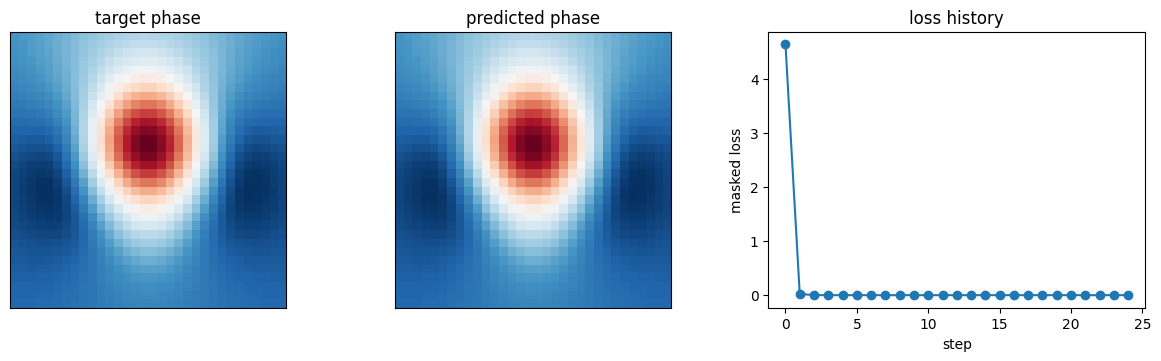

In [31]:
pred_final = np.asarray(
    forward_phase_from_density_and_magnetization(
        rho=rho,
        magnetization_3d=np.asarray(alpha * m_true_jax),
        pixel_size=pixel_size,
        axis="z",
    ),
    dtype=np.float32,
)
target_np = np.asarray(phase_target, dtype=np.float32)

plt.figure()
plt.imshow()

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), constrained_layout=True)
axes[0].imshow(target_np, cmap="RdBu_r")
axes[0].set_title("target phase")
axes[1].imshow(pred_final, cmap="RdBu_r")
axes[1].set_title("predicted phase")
axes[2].plot(loss_history, marker="o")
axes[2].set_title("loss history")
axes[2].set_xlabel("step")
axes[2].set_ylabel("masked loss")
for ax in axes[:2]:
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()
